# Практика: тренируемся генерировать картинки

## Описание задачи

В категории краткосрочной аренды выкладывается большое количество фейковых объявлений, из-за чего случаев мошенничества становится больше. При размещении в данной категории необходимо дополнительно сфотографировать листок с числовым кодом от авито для подтверждения владения собственности. Обработка всех таких фото занимет много человеко-часов, поэтому необходимо обучить модель, которая будет распознавать написанный код. Давайте попробуем решить ее генерацией картинок!

In [1]:
ls /kaggle/input/competitions/train-ocr-using-synth-data/ocr-synth

data/  fonts-main/  lib/  test/  val/


In [2]:
import os
from typing import Callable, Iterable
import shutil
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
from random import randint

import numpy as np
import pandas as pd
import albumentations as A
import torch

print("NumPy:", np.__version__)
print("Albumentations:", A.__version__)
print("PyTorch:", torch.__version__)

NumPy: 2.0.2
Albumentations: 2.0.8
PyTorch: 2.9.0+cu126


In [3]:
import sys
sys.path.append('/kaggle/input/competitions/train-ocr-using-synth-data/ocr-synth')

from lib.datasets import CustomDataset
from lib.model import Model
from lib.utils import train_model, try_test, get_fonts

2026-03-26 20:29:22.728270: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774556962.973755      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774556963.046168      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774556963.667795      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774556963.667835      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774556963.667838      55 computation_placer.cc:177] computation placer alr

In [4]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
seed_everything(2023)

In [5]:
TEST_PATH = '/kaggle/input/competitions/train-ocr-using-synth-data/ocr-synth/test/'
VAL_PATH = '/kaggle/input/competitions/train-ocr-using-synth-data/ocr-synth/val/'
FONTS_DIRECTORY = '/kaggle/input/competitions/train-ocr-using-synth-data/ocr-synth/fonts-main/'
EXAMPLE_FONT_DIRECTORY = '/kaggle/input/competitions/train-ocr-using-synth-data/ocr-synth/fonts-main/apache/smokum/Smokum-Regular.ttf'
GENERATED_DATA_DIRECTORY = '/kaggle/working/generated_data'
BACKGROUND_IMAGES_PATH = '/kaggle/input/competitions/train-ocr-using-synth-data/ocr-synth/data/'
params = {
    "dict_size" : 11,
    "seq_len" : 20,
    "hidden_size": 128
}
MODELS_DIRECTORY = '/kaggle/working/models/'

In [19]:
some_test_ids = ['0124423425', '101853096', '103020815', '104783333', '1049272', '105566453']

In [20]:
_, _, images_names = list(os.walk(VAL_PATH))[0]
images = []
some_test_images = []
for image_name in images_names:
    image_path = os.path.join(VAL_PATH, image_name)
    image = Image.open(image_path)
    images.append(image)
    if any([test_id in image_path for test_id in some_test_ids]):
        some_test_images.append(image)

## Посмотрим на разнообразие тестовых примеров

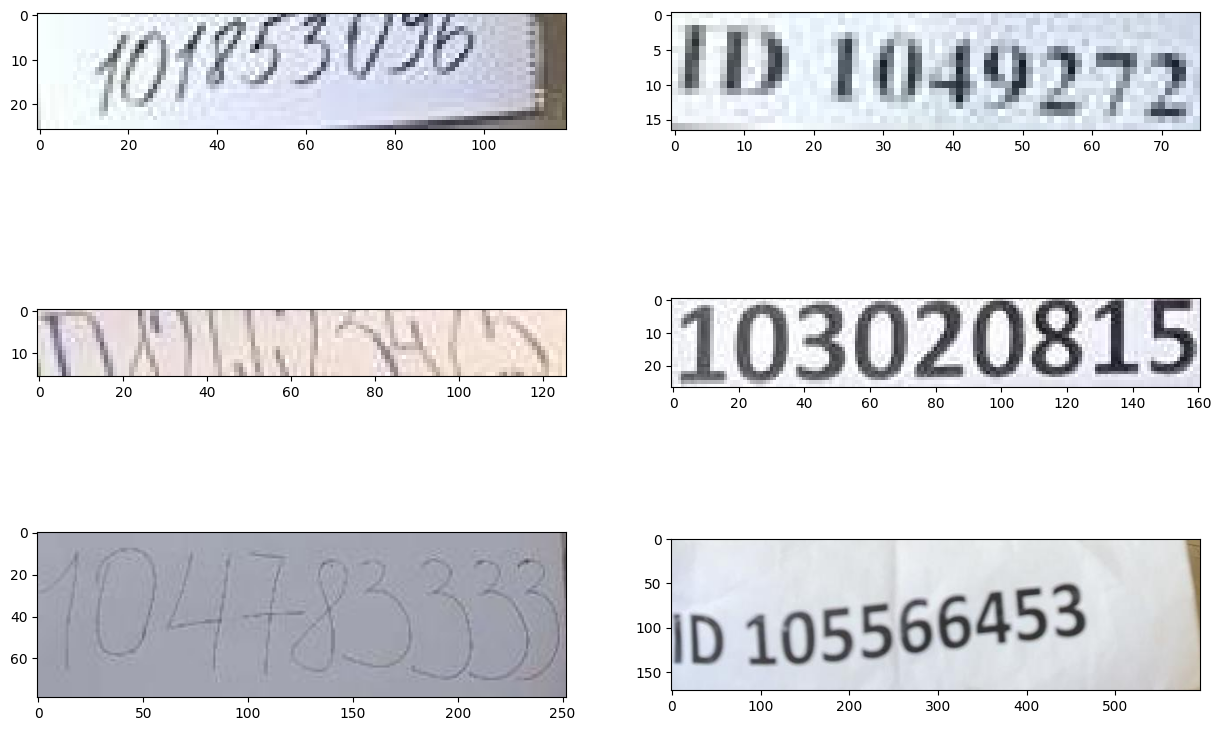

In [21]:
_, axs = plt.subplots(nrows=3, ncols=2, figsize=(15, 10))
axs = axs.flatten()
for img, ax in zip(some_test_images, axs):
    ax.imshow(img)
plt.show()

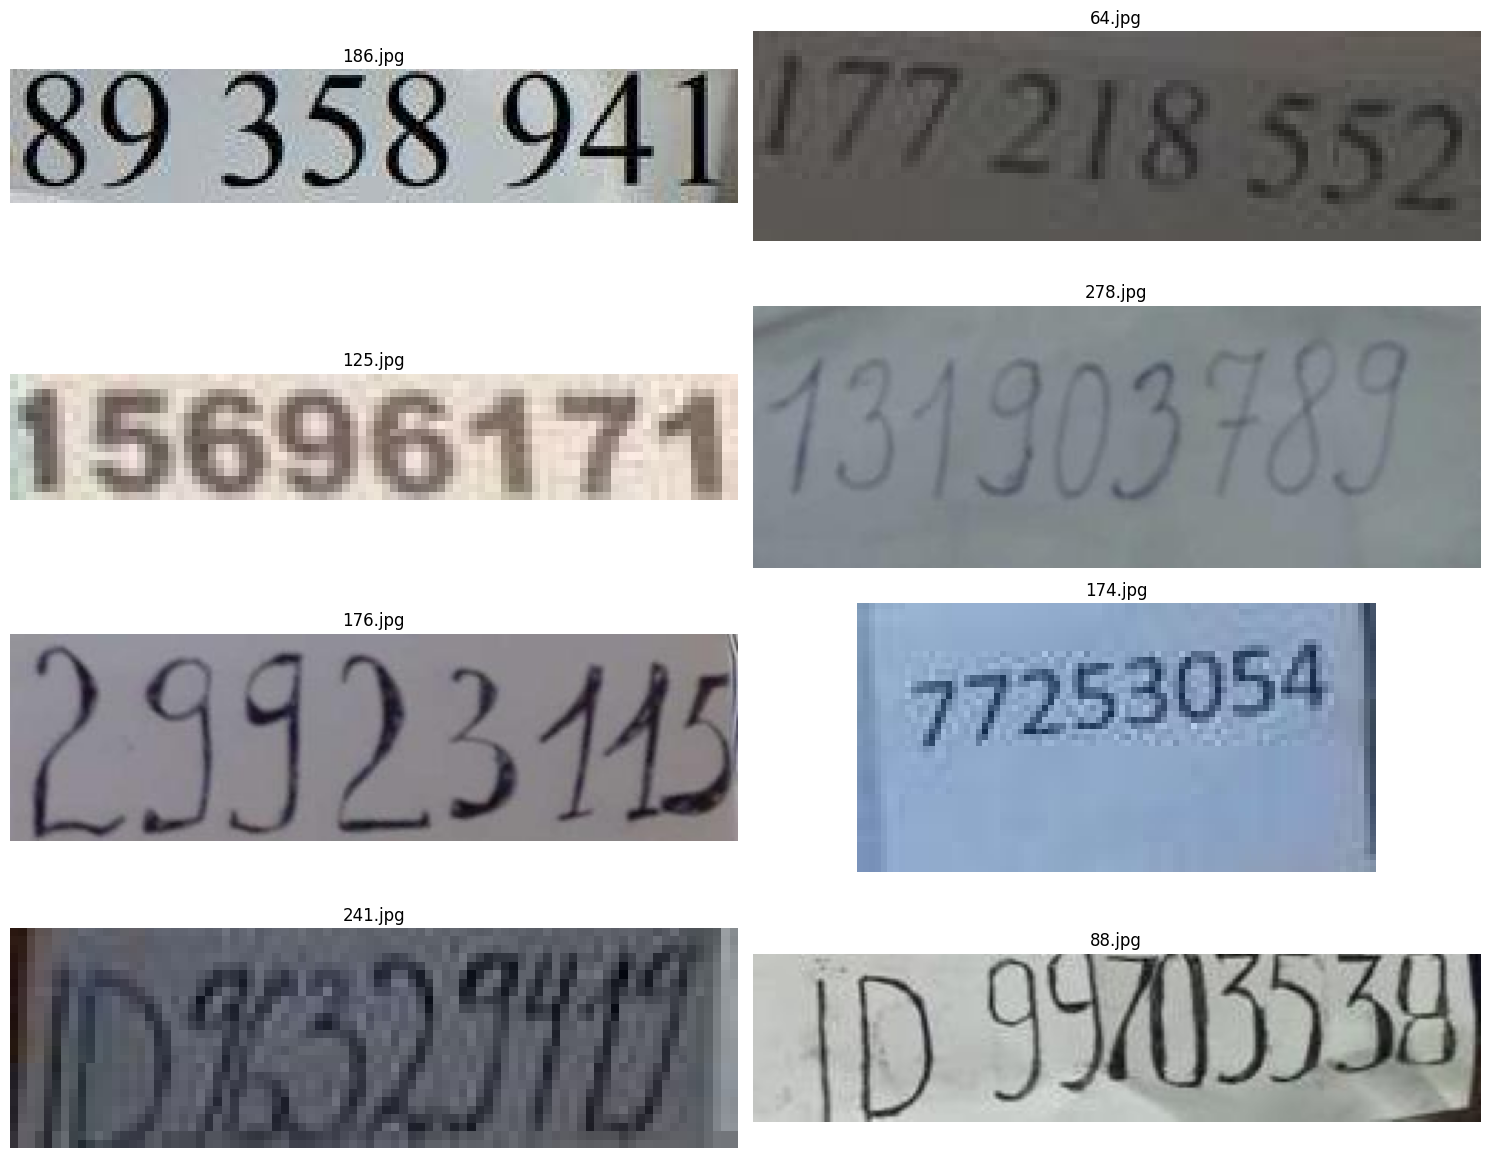

In [36]:
test_images_names = os.listdir(TEST_PATH)

random_test_names = random.sample(test_images_names, 8)

fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(15, 12))
axs = axs.flatten()

for img_name, ax in zip(random_test_names, axs):
    img_path = os.path.join(TEST_PATH, img_name)
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(img_name) 
    ax.axis('off')   

plt.tight_layout()
plt.show()

## Пробуем простую генерацию

### Настройки генерации

In [44]:
def get_text_dimensions(text_string, font):
    ascent, descent = font.getmetrics()

    text_width = font.getmask(text_string).getbbox()[2]
    text_height = font.getmask(text_string).getbbox()[3] + descent

    return (text_width, text_height)

In [45]:
def tensor_to_image(tensor_image):
    np_array_image = tensor_image.cpu().detach().numpy()
    uint_array = (np_array_image * 255).astype(np.uint8)[0, :, :]
    return uint_array

In [60]:
def plot_generated_images(iterator, nrows=2, ncols=2, figsize=(15, 10)):
    _, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axs = axs.flatten()
    for item, ax in zip(iterator, axs):
        img = tensor_to_image(item['image'])
        ax.imshow(img, cmap='gray')
        ax.set_title(item['text'])
        
    plt.show()

In [51]:
NUM_IMAGES_TO_GENERATE = 15000 

def generate_image(font, directory_to_save, get_paper, get_colors, images_background):
    length = randint(3, 10) 

    # чистый ответ
    pure_digits = ''.join([str(randint(0, 9)) for _ in range(length)])
    random_number = pure_digits

    # добавим мусора
    visual_text = ""
    for digit in pure_digits:
        visual_text += digit
        if random.random() < 0.3:
            visual_text += " " * randint(1, 3) 
            
    visual_text = visual_text.strip()
    
    if random.random() < 0.2:
        prefix = random.choice(["ID ", "id ", "Id ", "ID: ", "id: ", "ID-"])
        visual_text = prefix + visual_text
        
    random_number_text = visual_text
    
    try:
        text_width, text_height = get_text_dimensions(text_string=random_number_text, font=font)
    except Exception:
        return 

    if text_width > 4000 or text_height > 4000 or text_width <= 0 or text_height <= 0:
        return

    paper = get_paper(
        text_width=text_width, 
        text_height=text_height,
        images_background=images_background
    )

    rgb = get_colors()
    paper_drawing = ImageDraw.Draw(paper)
    paper_drawing.text((0, 0 - int(text_height*0.21)), random_number_text, font=font, fill=rgb)

    path_to_save = os.path.join(directory_to_save, f'{random_number}.jpg')
    
    try:
        paper.save(path_to_save)
    except OSError:
        pass


def generate_images(directory_to_save: str, 
                    get_font: Callable, 
                    get_paper: Callable,
                    get_colors: Callable,
                    images_background: Iterable,
                    num_images_to_generate: int, 
                    delete_directory = False):
    if delete_directory and os.path.exists(directory_to_save):
        shutil.rmtree(directory_to_save)
    os.makedirs(directory_to_save)
    for _ in tqdm(range(num_images_to_generate)):
        font = get_font()
        generate_image(
            font=font,
            directory_to_save=directory_to_save,
            get_paper=get_paper,
            get_colors=get_colors,
            images_background=images_background
        )

In [52]:
_, _, images_names = list(os.walk(BACKGROUND_IMAGES_PATH))[0]
images_background = [
    Image.open(
        os.path.join(BACKGROUND_IMAGES_PATH, name)
    ) for name in images_names
]

In [53]:
fonts_path = get_fonts(FONTS_DIRECTORY)
tag = 'baseline'
directory_to_save = os.path.join(GENERATED_DATA_DIRECTORY, tag)

def get_font():
    random_font_path = fonts_path[randint(0, len(fonts_path) - 1)]
    random_font_size = randint(75, 125)
    font = ImageFont.truetype(font=random_font_path, size=random_font_size)
    return font

def get_paper(text_width, text_height, images_background):
    bg_image = images_background[randint(0, len(images_background) - 1)]
    
    pad_w = int(text_width * random.uniform(0.1, 0.4))
    pad_h = int(text_height * random.uniform(0.1, 0.5))
    
    crop_width = text_width + pad_w
    crop_height = text_height + pad_h
    
    bg_w, bg_h = bg_image.size
    
    if bg_w < crop_width or bg_h < crop_height:
        bg_image = bg_image.resize((max(bg_w, crop_width), max(bg_h, crop_height)))
        bg_w, bg_h = bg_image.size

    x1 = randint(0, bg_w - crop_width)
    y1 = randint(0, bg_h - crop_height)

    paper = bg_image.crop((x1, y1, x1 + crop_width, y1 + crop_height))
    return paper


def get_colors():
    choice = random.random()
    if choice < 0.4:
        val = randint(0, 60)
        return (val, val, val)
    elif choice < 0.8:
        return (randint(0, 40), randint(0, 50), randint(80, 180))
    else:
        return (randint(0, 100), randint(0, 80), randint(0, 150))

### Генерация изображений

In [54]:
directory_to_save = os.path.join(GENERATED_DATA_DIRECTORY, tag)
generate_images(
    directory_to_save=directory_to_save, 
    get_font=get_font,
    get_paper=get_paper,
    get_colors=get_colors,
    num_images_to_generate=NUM_IMAGES_TO_GENERATE,
    delete_directory=True,
    images_background=images_background
)

100%|██████████| 15000/15000 [01:52<00:00, 133.33it/s]


### Аугментации

In [70]:
import cv2

train_preprocess = A.Compose([
    A.OneOf([
        A.Rotate(limit=10, border_mode=cv2.BORDER_CONSTANT, fill=255, p=1.0),
        A.Perspective(scale=(0.02, 0.05), fit_output=False, p=1.0), 
    ], p=0.5),

    A.OneOf([
        A.MotionBlur(blur_limit=3, p=1.0),
        A.GaussianBlur(blur_limit=3, p=1.0),
    ], p=0.3),

    A.CoarseDropout(
        num_holes_range=(1, 5), 
        hole_height_range=(2, 4), 
        hole_width_range=(2, 4), 
        fill=255, 
        p=0.3
    ),
])

### Датасет

In [73]:
generated_dataset = CustomDataset(
    images_folder_path=directory_to_save, 
    data_type='train',
    train_preprocess=train_preprocess
)
train_dataloader = generated_dataset.get_dataloader()
iterator = iter(generated_dataset)

val_dataset = CustomDataset(
    images_folder_path=VAL_PATH, 
    data_type='test', 
)
val_dataloader = val_dataset.get_dataloader()
val_iterator = iter(val_dataset)

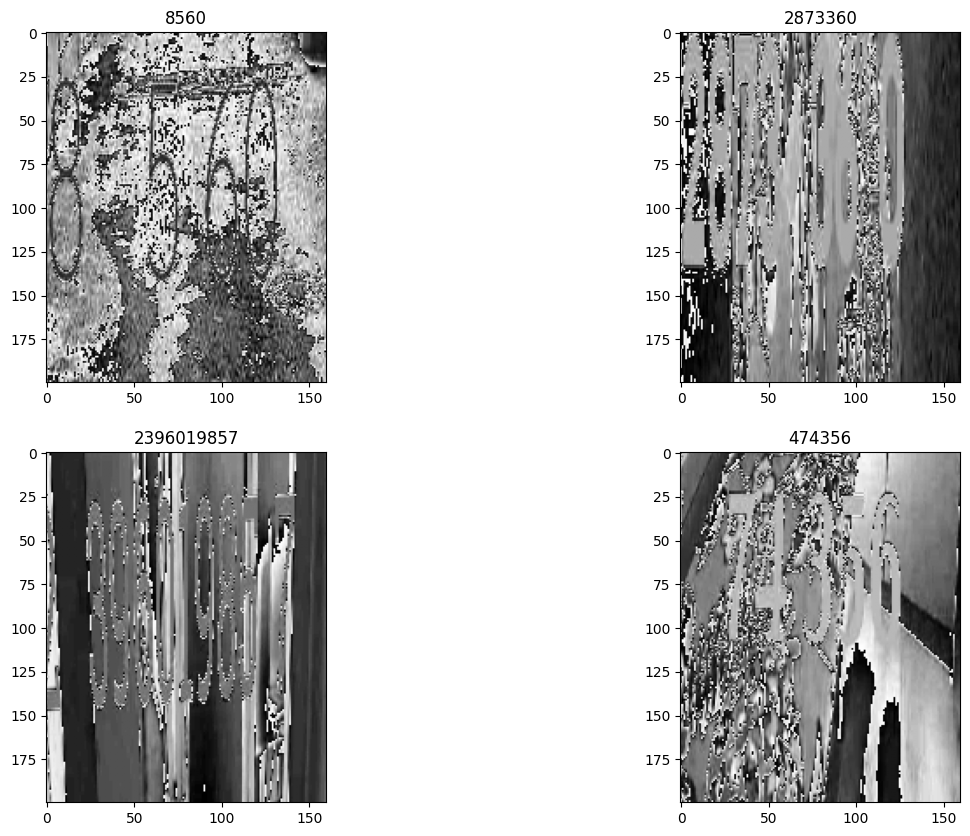

In [74]:
plot_generated_images(iterator)

In [86]:
os.makedirs(MODELS_DIRECTORY, exist_ok=True)

### Модель

In [76]:
EPOCHS = 15
train_model(
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    epochs=EPOCHS,
    tag=tag,
    dev='cuda:0'
)

  0%|          | 0/862 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `char_error_rate` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `char_error_rate` from `torchmetrics.text` instead.
  _future_warning(


char error rate: 0.969 || test_loss:204.076 ||


  0%|          | 0/862 [00:00<?, ?it/s]

char error rate: 0.608 || test_loss:158.38 ||


...

char error rate: 0.421 || test_loss:133.585 ||


  0%|          | 0/862 [00:00<?, ?it/s]

char error rate: 0.403 || test_loss:77.417 ||


  0%|          | 0/862 [00:00<?, ?it/s]

char error rate: 0.409 || test_loss:91.048 ||


In [81]:
tag

'baseline'

In [82]:
params = {
    "dict_size" : 11, # letters size
    "seq_len" : 20,
    "hidden_size": 128
}


dev = 'cuda:0'
model = Model(params).to(dev)
path_to_model = os.path.join(MODELS_DIRECTORY, tag + '_' + 'model.pt')
model.load_state_dict(torch.load(path_to_model))

<All keys matched successfully>

In [84]:
test_dataset = CustomDataset(
    images_folder_path=TEST_PATH, 
    data_type='test',
)
test_dataloader = test_dataset.get_dataloader()

In [85]:
pbar = tqdm(test_dataloader)
answers = []
for item in pbar:
    ans = try_test(model, item, params, dev)[0]
    ans_df = pd.DataFrame(ans, columns=['image_id', 'model_answer'])
    answers.append(ans_df)
answers_df = pd.concat(answers, ignore_index=True)
answers_df.to_csv('result_1.csv', index=False)

100%|██████████| 16/16 [00:02<00:00,  5.55it/s]


In [ ]:
answers_df